<a href="https://colab.research.google.com/github/Fahadqureshi0/Transfer-Learning-using-CNNs/blob/main/Transfer_Learning_using_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installing Kaggle
!pip install kaggle

In [2]:
!mkdir -p ~/.Kaggle
!cp kaggle.json ~/.Kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [ ]:
# Downloading Dataset
!kaggle datasets download -d tongpython/cat-and-dog

In [4]:
# Unzipping Dataset
from zipfile import ZipFile

dataset = "/content/cat-and-dog.zip"

with ZipFile(dataset, "r") as zip:
  zip.extractall()
  print("Dataset Etracted")

Dataset Etracted


In [5]:
# Importing Dependencies
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten
from keras.applications.vgg16 import VGG16

In [15]:
conv_base = VGG16(
    weights = "imagenet",
    include_top = False,
    input_shape = (150, 150, 3)
)

In [16]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Sequential Model from Stratch
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation= 'relu'))
model.add(Dense(1, activation= 'sigmoid'))

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
conv_base.trainable = False

In [17]:
# Generators
train_dataset = keras.utils.image_dataset_from_directory(
    directory = "/content/training_set/training_set",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (150, 150)
)

# Test Dataset
test_dataset = keras.utils.image_dataset_from_directory(
    directory = "/content/test_set/test_set",
    labels = "inferred",
    label_mode = "int",
    batch_size = 32,
    image_size = (150, 150)
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [18]:
# Labels
# Cat --> 0
# Dog --> 1

In [19]:
# Normalize Pixels
def process(image, label):
  image = tensorflow.cast(image/255. , tensorflow.float32)
  return image, label

train_dataset = train_dataset.map(process)
test_dataset = test_dataset.map(process)

In [21]:
# Compiling model
model.compile(optimizer = "adam", loss="binary_crossentropy", metrics=['accuracy'])

In [22]:
# Fitting Data to model
history = model.fit(train_dataset, epochs=10, validation_data=test_dataset)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 54s 170ms/step - accuracy: 0.8545 - loss: 0.3513 - val_accuracy: 0.8937 - val_loss: 0.2346
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - accuracy: 0.9128 - loss: 0.1985 - val_accuracy: 0.8967 - val_loss: 0.2448
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/step - accuracy: 0.9347 - loss: 0.1605 - val_accuracy: 0.8898 - val_loss: 0.2677
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.9553 - loss: 0.1149 - val_accuracy: 0.9066 - val_loss: 0.2510
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/step - accuracy: 0.9611 - loss: 0.0986 - val_accuracy: 0.9071 - val_loss: 0.2615
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/step - accuracy: 0.9653 - loss: 0.0860 - val_accuracy: 0.9036 - val_loss: 0.3011
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.9819 - loss: 0.0541 - val_accuracy: 0.9031 - val_loss: 0.3071
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/step - accuracy: 0.9773 - loss: 0

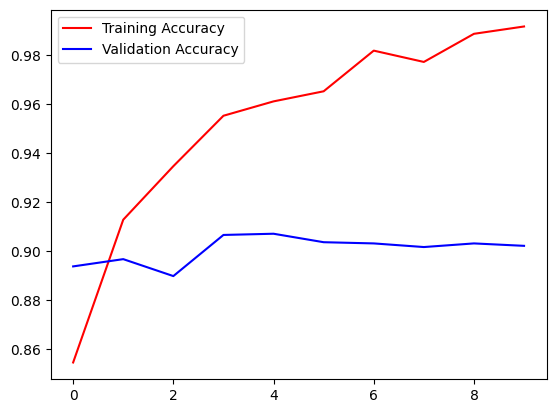

In [23]:
# Plotting (Labels & Validations Score)
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='Blue', label='Validation Accuracy')
plt.legend()
plt.show()

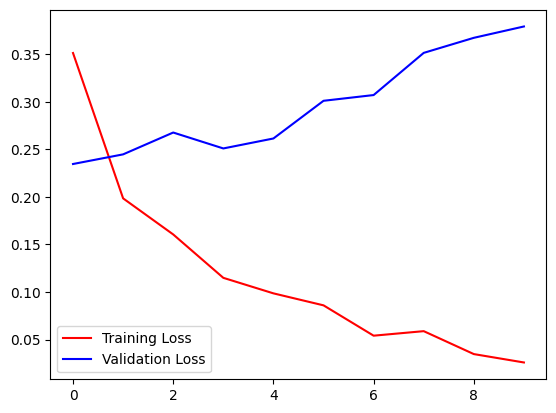

In [25]:
plt.plot(history.history['loss'], color='red', label='Training Loss')
plt.plot(history.history['val_loss'], color='Blue', label='Validation Loss')
plt.legend()
plt.show()

**Saving Model**

In [26]:
model.save("cat_dog_vgg16.keras")

**Loading Saved Model**

In [27]:
from tensorflow.keras.models import load_model
model = load_model("/content/cat_dog_vgg16.keras")

**Importing Dependencies**

In [28]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

In [36]:
# Image Path
img_path = "/content/test_set/test_set/cats/cat.4002.jpg"

# Loading Image
img = image.load_img(img_path, target_size=(150, 150))

**Converting Image to Numpy Array**

In [37]:
# Convert image to NumPy array
img_array = image.img_to_array(img)

In [38]:
# Adding Batch Dimension
img_array = np.expand_dims(img_array, axis=0)

In [39]:
# VGG16 preprocessing
img_array = preprocess_input(img_array)

In [40]:
# Prediction
prediction = model.predict(img_array, verbose=0)

In [41]:
# Get probability
probability = prediction[0][0]

In [42]:
# Classify
if probability >= 0.5:
    print("Prediction: 🐶 Dog")
    print("Confidence:", round(probability * 100, 2), "%")
else:
    print("Prediction: 🐱 Cat")
    print("Confidence:", round((1 - probability) * 100, 2), "%")

Prediction: 🐶 Dog
Confidence: 100.0 %
